<a href="https://colab.research.google.com/github/nainy-sara/convolutional-neural-networks/blob/main/cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy as np
import torch #pytorch
import torch.nn as nn
from skimage.data import shepp_logan_phantom
from google.colab.patches import cv2_imshow
import cv2

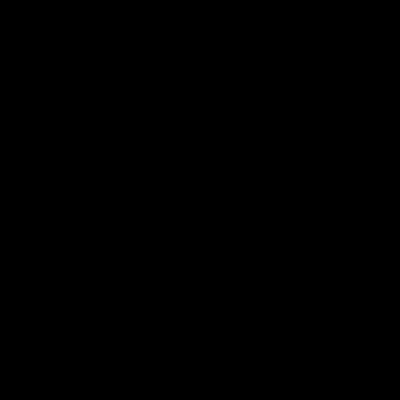

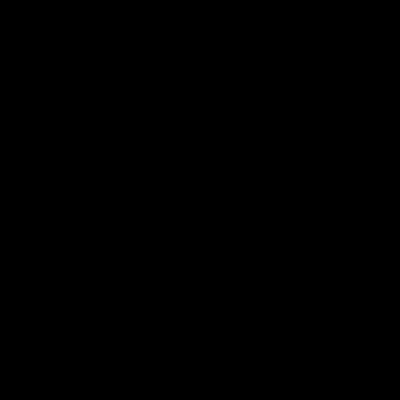

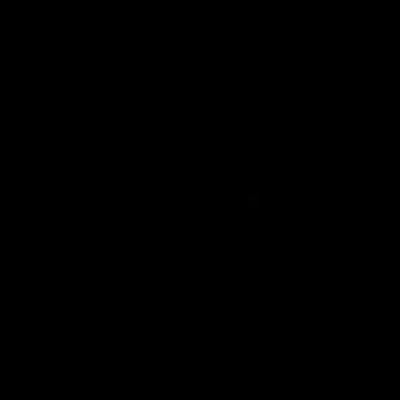

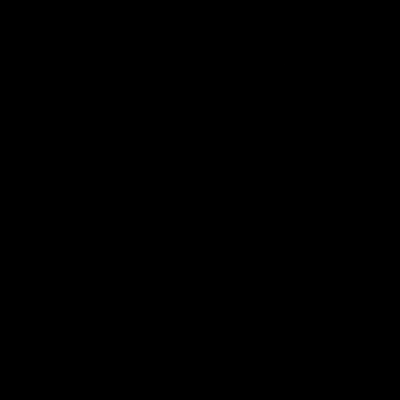

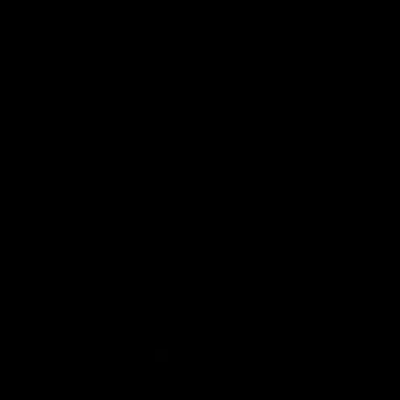

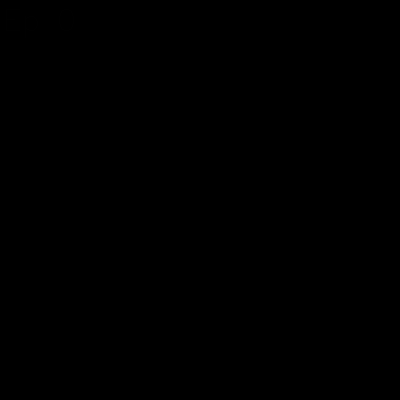

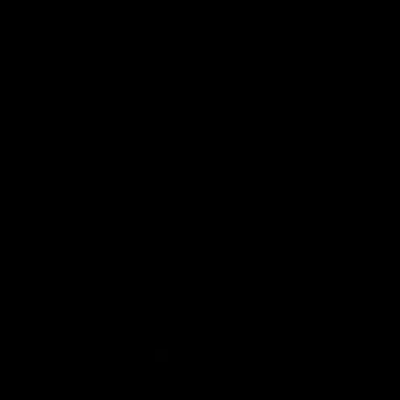

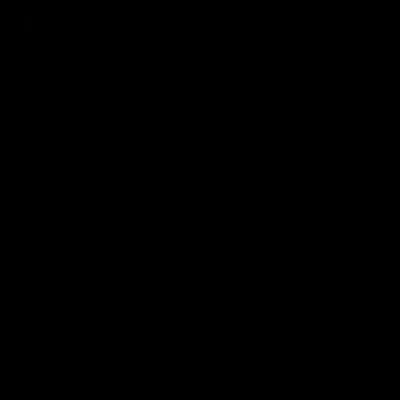

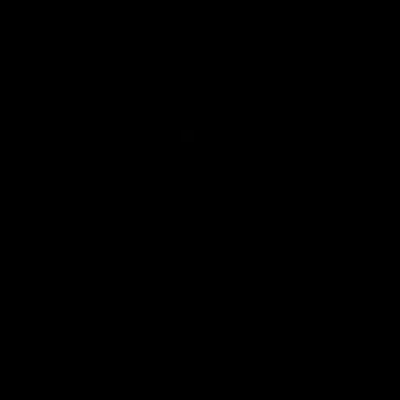

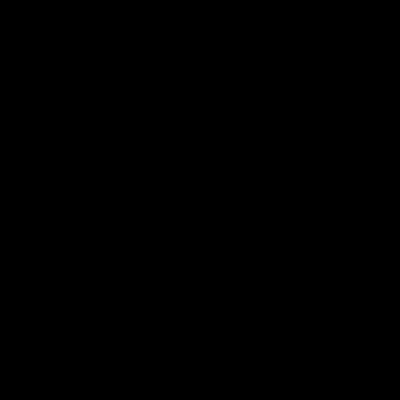

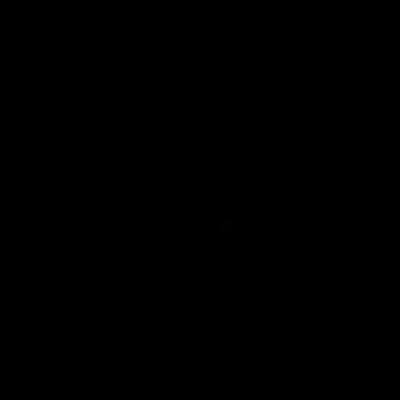

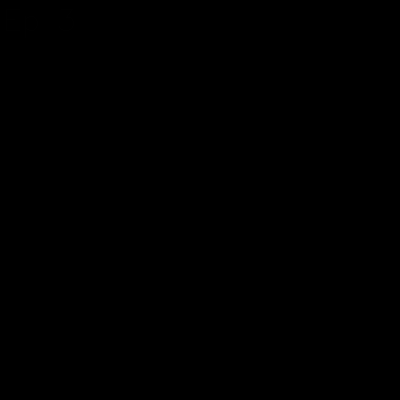

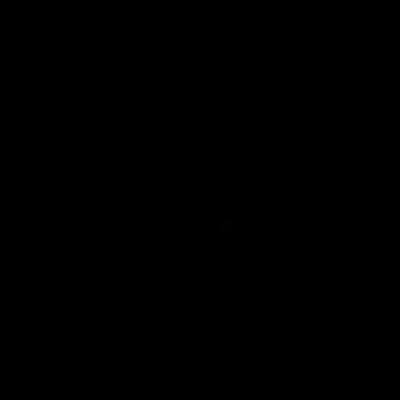

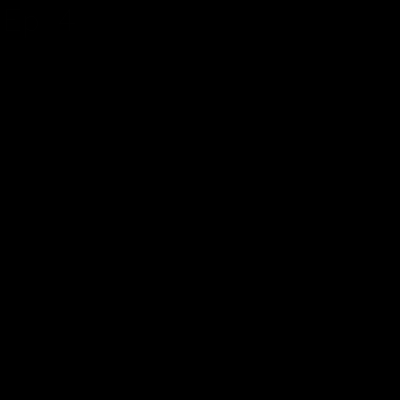

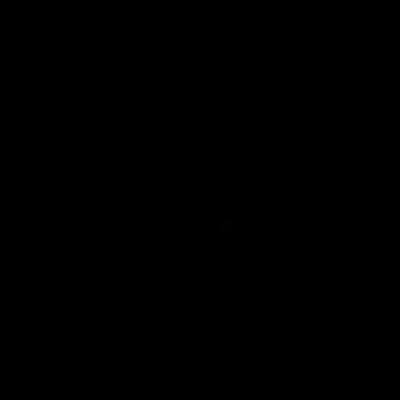

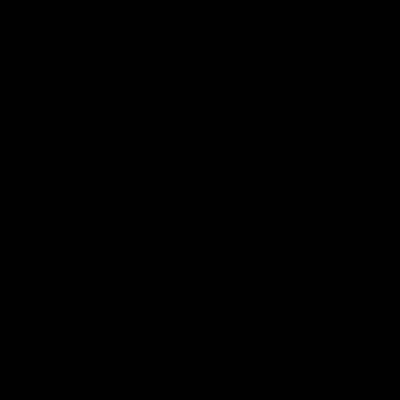

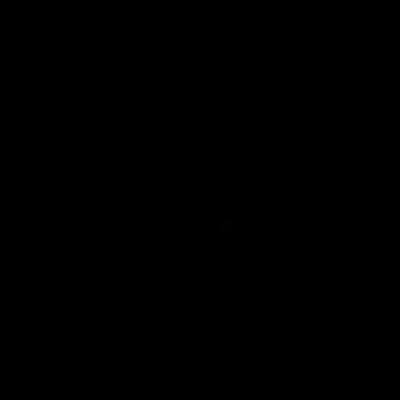

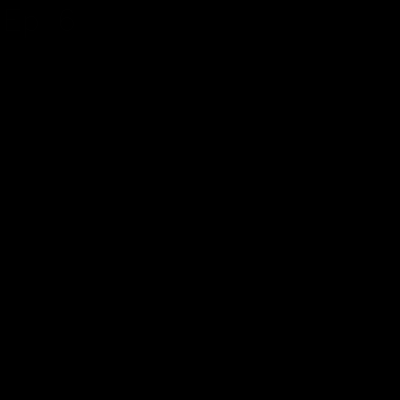

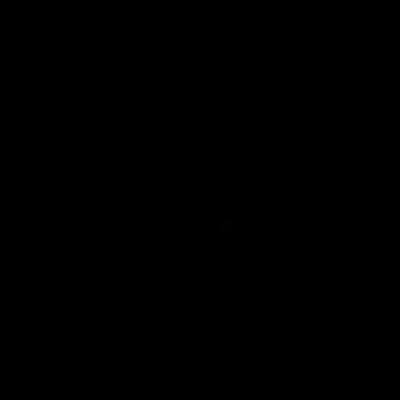

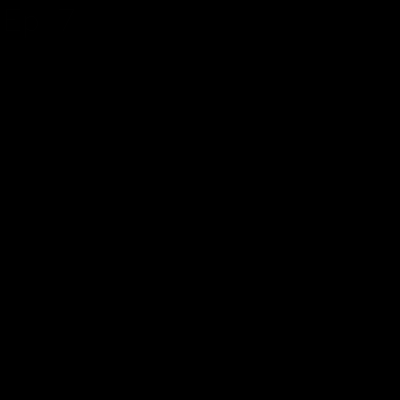

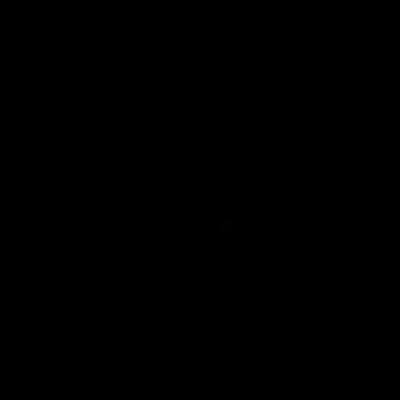

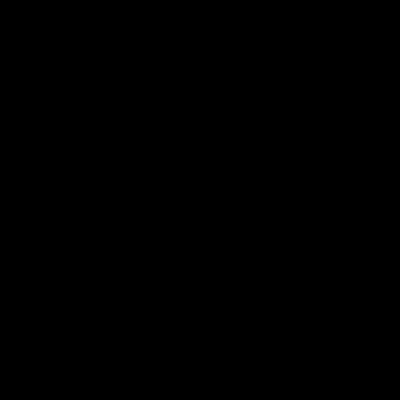

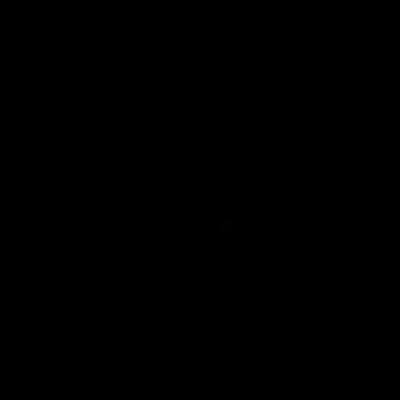

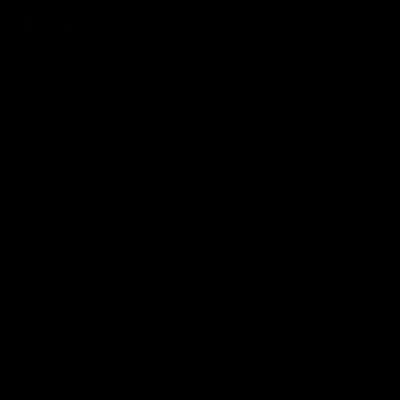

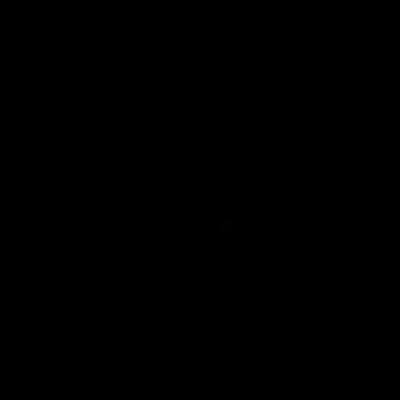

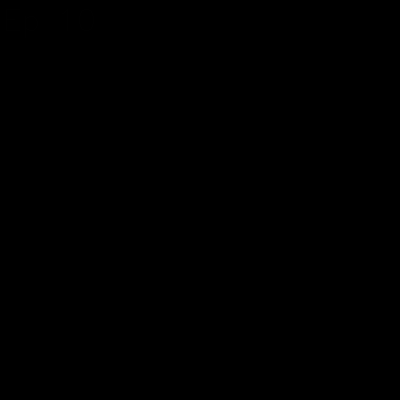

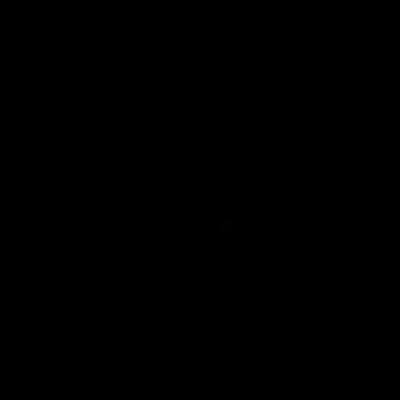

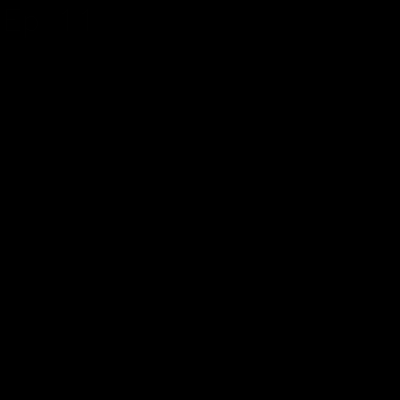

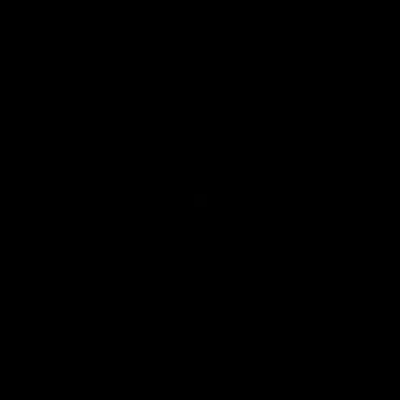

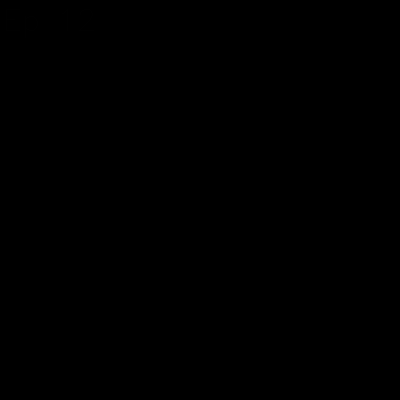

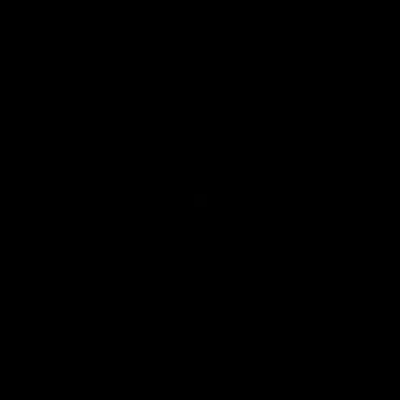

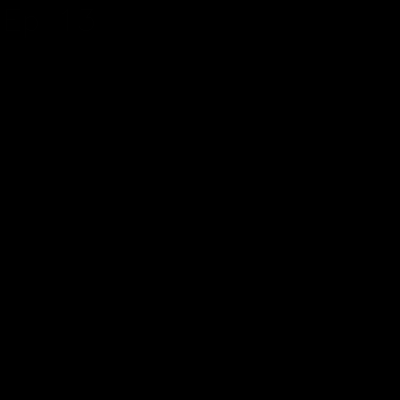

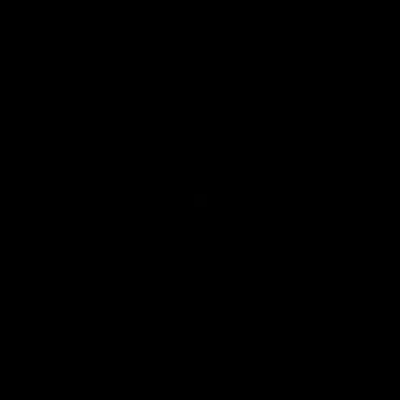

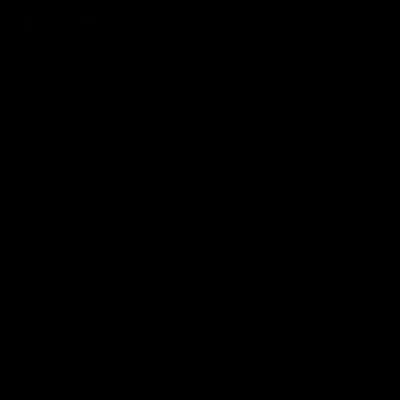

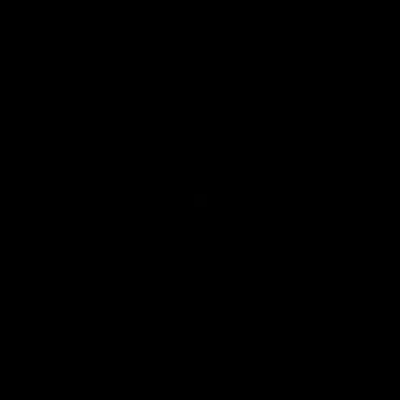

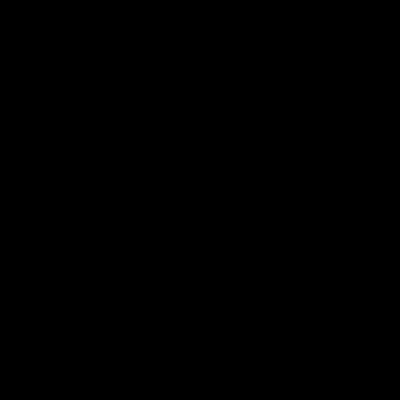

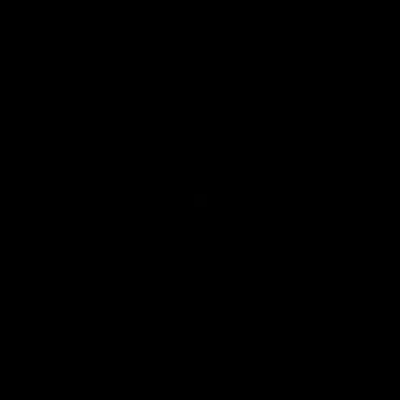

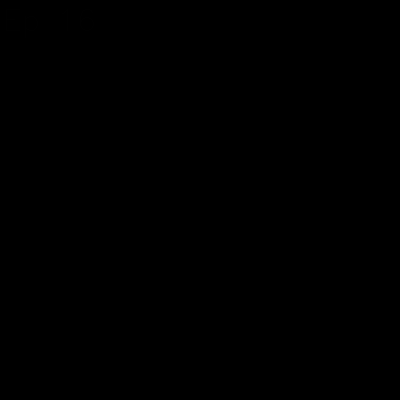

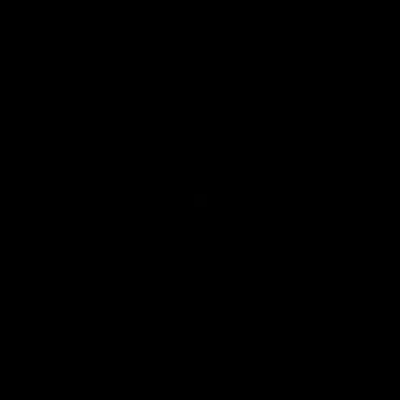

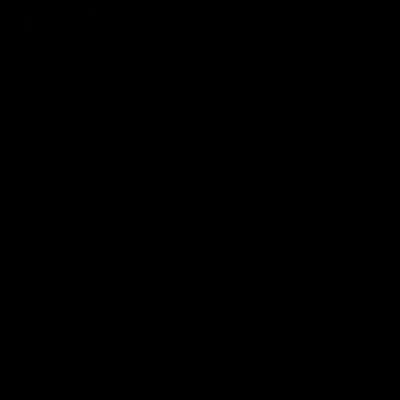

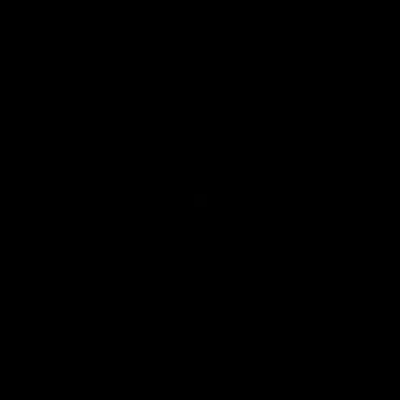

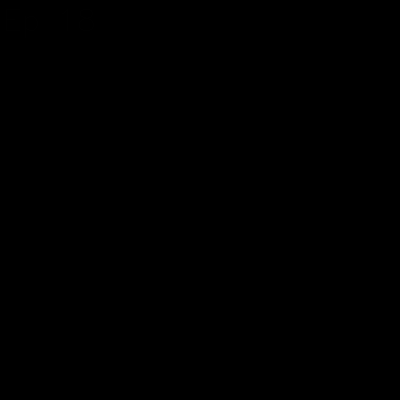

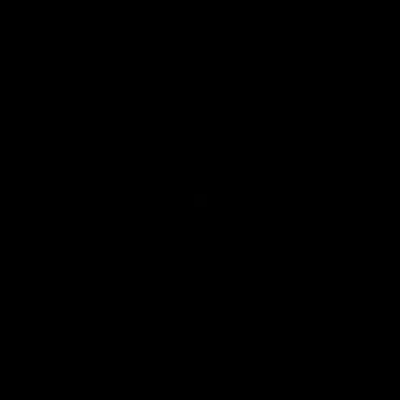

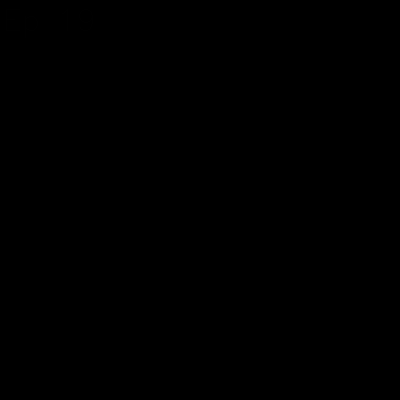

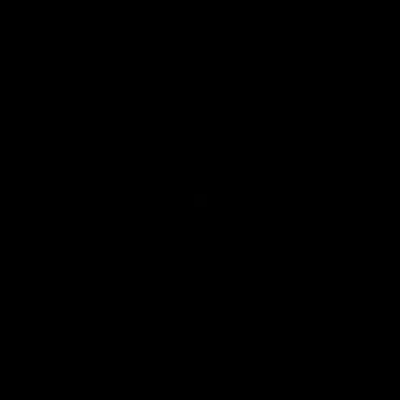

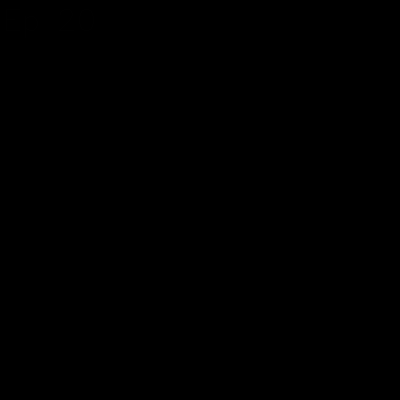

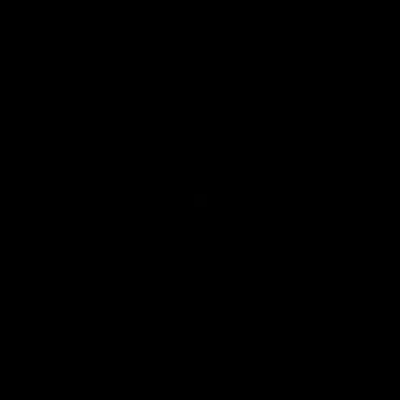

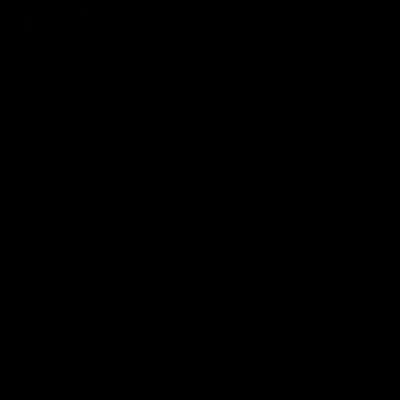

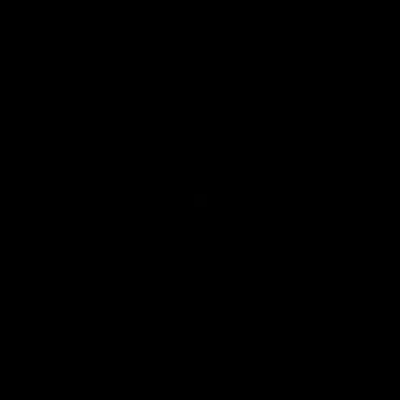

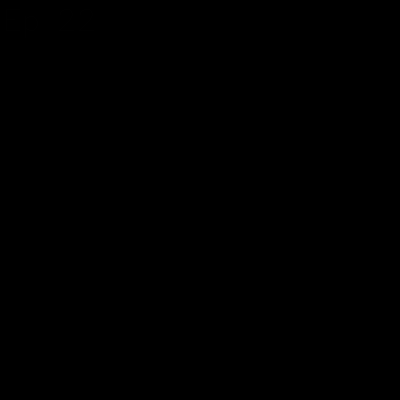

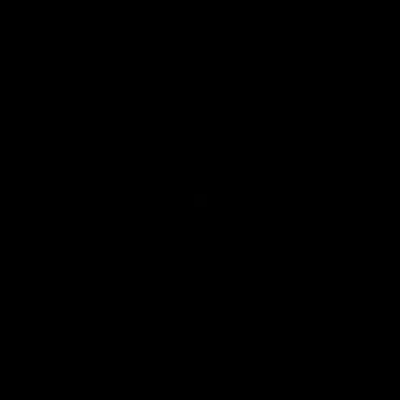

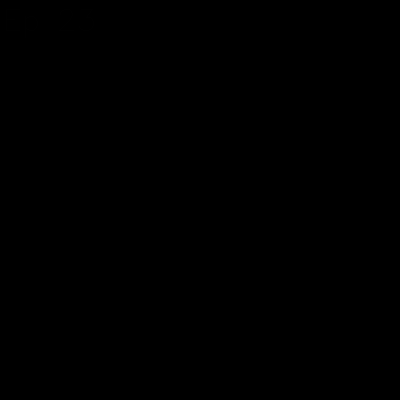

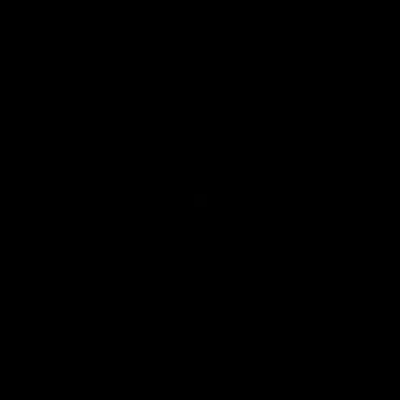

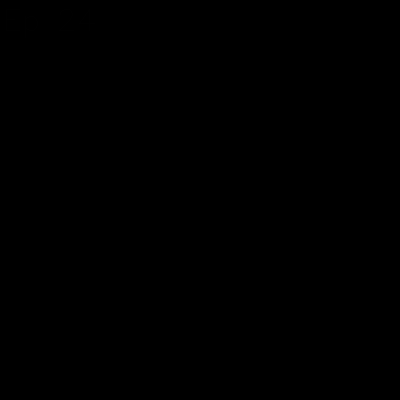

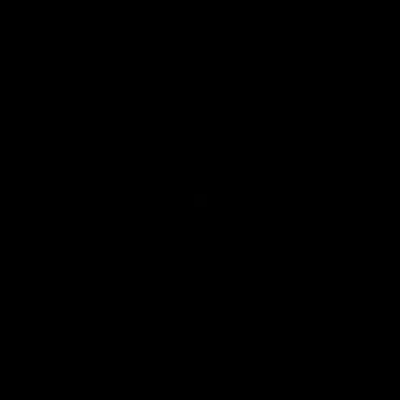

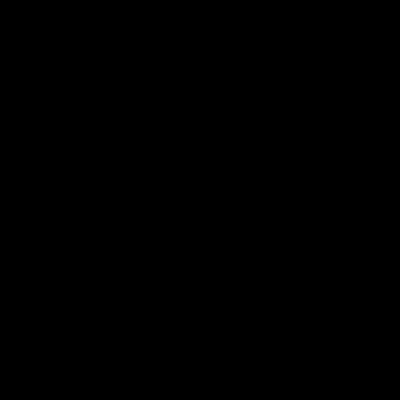

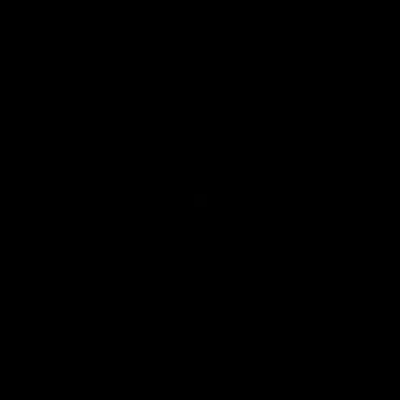

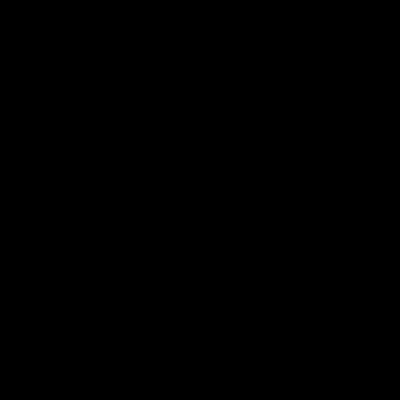

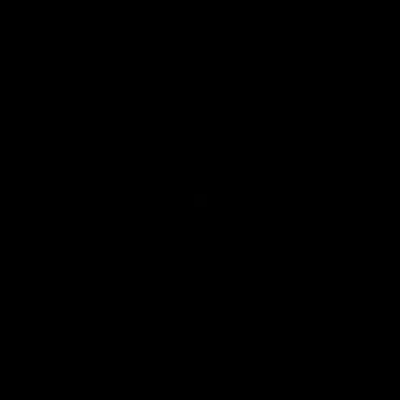

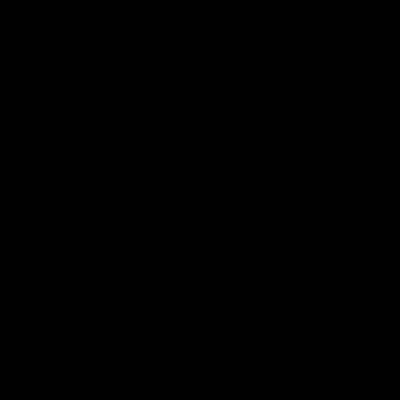

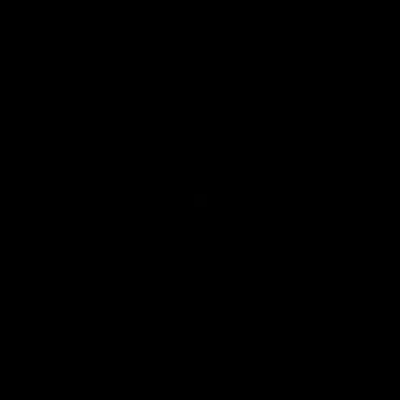

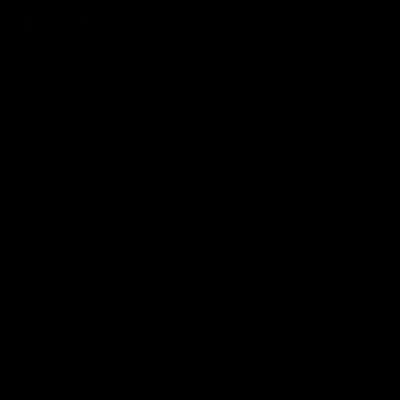

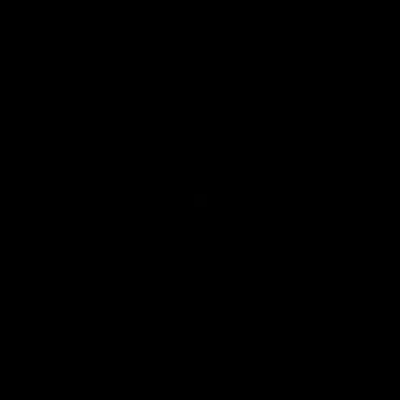

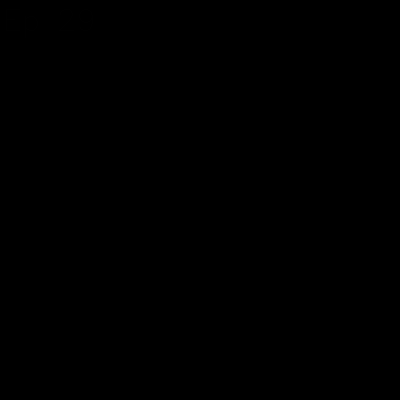

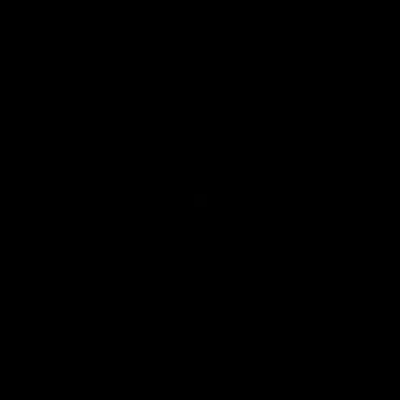

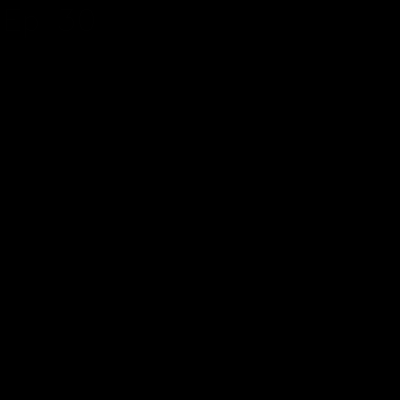

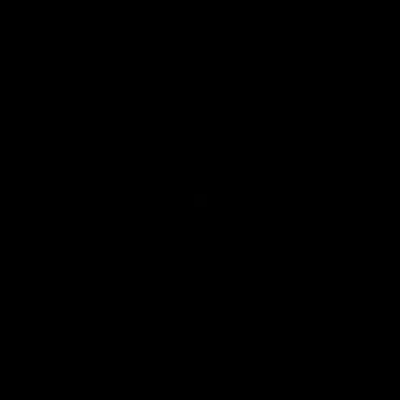

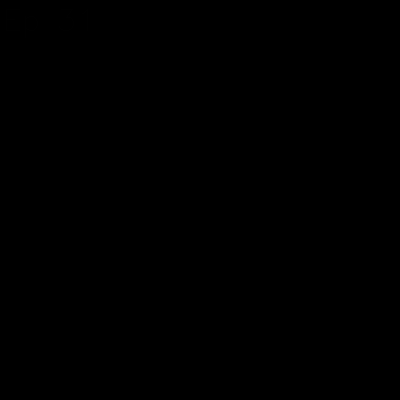

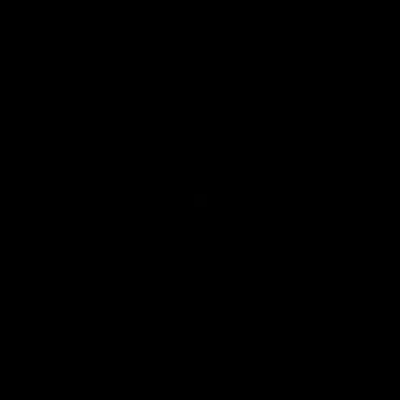

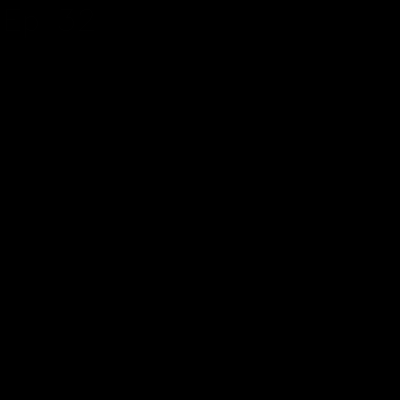

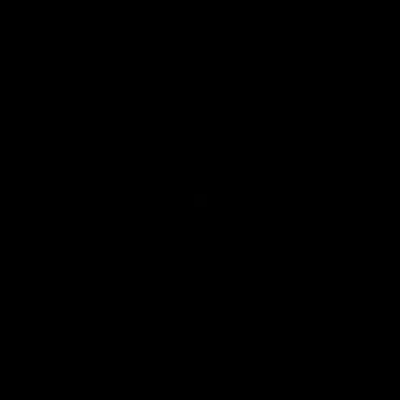

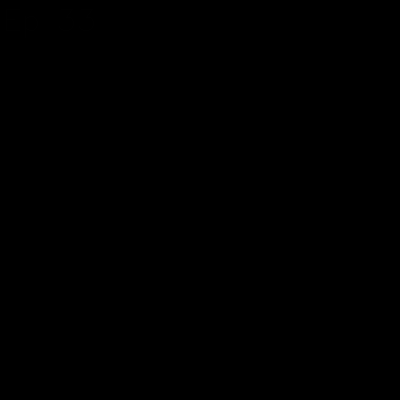

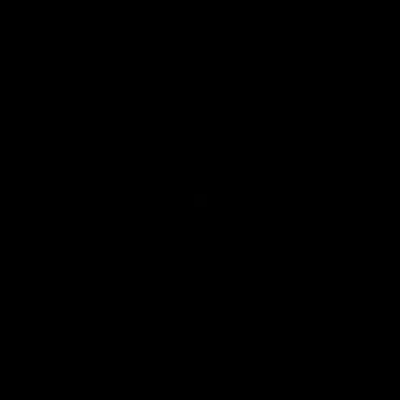

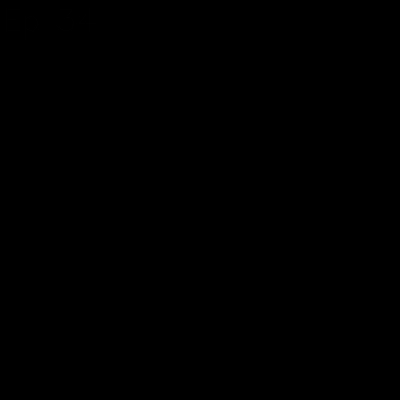

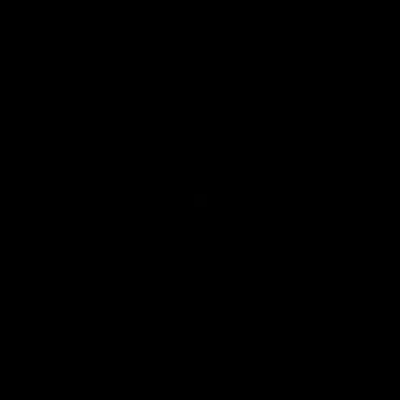

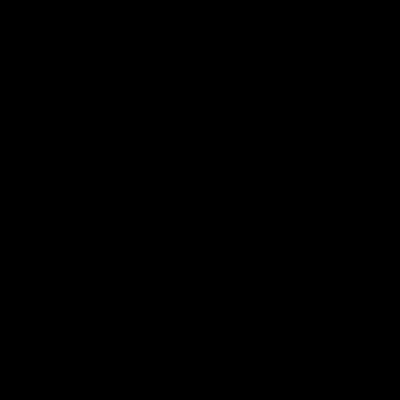

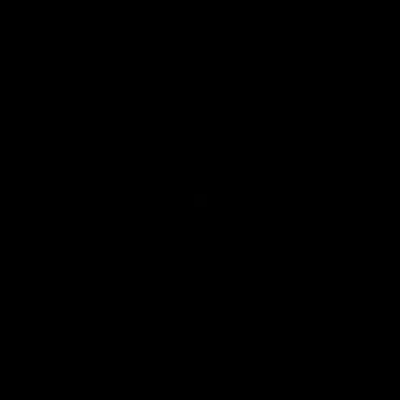

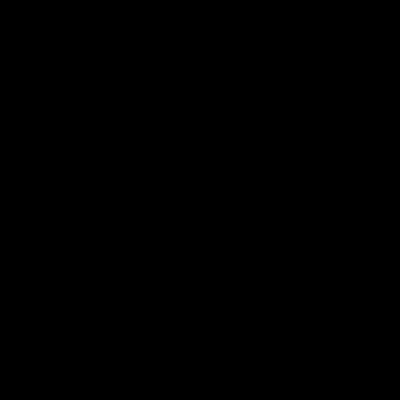

In [ ]:


true_np = shepp_logan_phantom()
noisy_np = np.random.poisson(true_np)

def cv2disp(name, image, xpos, ypos) : cv2_imshow(image*1.0/(np.max(image)+1e-15)); #cv2.moveWindow(name, xpos, ypos) #cv2.moveWindow is not working in Colab

nxd = true_np.shape[0]


cv2disp('true', true_np, 0, 0)
cv2disp('noisy', noisy_np, nxd, 0)

class Convolution_NxN(nn.Module):
    def __init__(self, kernal_size):
        super(Convolution_NxN, self).__init__()
        self.conv1kernal = nn.Conv2d(1, 1, kernal_size, padding=(int(kernal_size/2), int(kernal_size/2)), bias=False)
        #self.conv1kernal.weight.data.fill_(1.0/(kernal_size*kernal_size))

    def forward(self, x):
            x = self.conv1kernal(x)
            return x

noisy_torch    = torch.from_numpy(noisy_np).float().unsqueeze(0).unsqueeze(0)

conv_fix_kernal = Convolution_NxN(31)

kernal_torch = list(conv_fix_kernal.parameters())[0]
cv2disp('kernel', cv2.resize(np.squeeze(kernal_torch.detach().numpy()), (nxd,nxd), interpolation = 0), 2*nxd, 0)

conv_out_torch = conv_fix_kernal(noisy_torch)
conv_out_np = np.squeeze(conv_out_torch.detach().numpy())

cv2disp('output of conv', conv_out_np, 3*nxd, 0)

con_trained_kernal = Convolution_NxN(31)
loss_function   = nn.MSELoss()
true_torch  = torch.from_numpy(true_np).float().unsqueeze(0).unsqueeze(0)
optimiser   = torch.optim.Adam(con_trained_kernal.parameters(), lr=0.003)

for epoch in range(500):
    output = con_trained_kernal(noisy_torch)
    loss = loss_function(output, true_torch)
    loss.backward()
    optimiser.step()
    optimiser.zero_grad()

    kernal_torch = list(con_trained_kernal.parameters())[0]
    cv2disp('trained kernel', cv2.resize(np.squeeze(kernal_torch.detach().numpy()), (nxd,nxd), interpolation = 0), 1*nxd, 30+nxd)

    cnn_output = np.squeeze(output.detach().numpy())
    cv2.putText(cnn_output, 'Ep %d' % epoch, (2,30), 0, 1, int(np.max(cnn_output)+1), 1, cv2.LINE_AA)
    cv2disp('output after trained conv', cnn_output, nxd*2, nxd+30)
    #cv2.waitKey(1)


class CNN(nn.Module):
    def __init__(self):
        super(CNN,self).__init__()
        self.CNN = nn.Sequential(
            nn.Conv2d(1, 8, 7, padding=(3,3)), nn.PReLU(),
            nn.Conv2d(8, 8, 7, padding=(3,3)), nn.PReLU(),
            nn.Conv2d(8, 8, 7, padding=(3,3)), nn.PReLU(),
            nn.Conv2d(8, 8, 7, padding=(3,3)), nn.PReLU(),
            nn.Conv2d(8, 1, 7, padding=(3,3)), nn.PReLU(),
        )

    def forward(self,x):
            x = self.CNN(x)
            return x

cnn_to_train = CNN()
loss_function = nn.MSELoss()
optimiser = torch.optim.Adam(cnn_to_train.parameters(), lr= 0.003)

for epoch in range(500):
    output = cnn_to_train(noisy_torch)
    loss = loss_function(output, true_torch)
    loss.backward()
    optimiser.step()
    optimiser.zero_grad()

    cnn_output = np.squeeze(output.detach().numpy())
    cv2.putText(cnn_output, 'Ep %d' % epoch, (2,30), 0, 1, int(np.max(cnn_output)+1), 1, cv2.LINE_AA)
    cv2disp('output after trained conv', cnn_output, nxd*3, nxd+30)
    cv2.waitKey(1)
cv2.waitKey(0)